# WTI Crude Oil Price Forecasting — Introducing the Agentic Predictor (Notebook 2 of 7)

This notebook introduces the **progressive capability staircase** for agentic
forecasting by studying a single, high-stakes prediction origin:
**March 2, 2026** — the day news of Persian Gulf shipping-lane disruptions
began reaching energy markets.

> **Prerequisite:** Run [`01_wti_case_study.ipynb`](01_wti_case_study.ipynb) first — it establishes why a price-only baseline fails during regime breaks.

We build four predictors of increasing sophistication, each implementing
the standard `Predictor` interface so that the outputs are directly
comparable and can slot into the systematic backtest in Notebook 4.

| Step | Predictor | Capability |
|------|-----------|------------|
| 1 | `ProphetPredictor` | Statistical baseline — extrapolates trend and seasonality |
| 2 | `SampledTrajectoryLLMPredictor` | Direct-prompting LLMP — no tools, reasons from history text |
| 3 | `AgentPredictor` (news) | News-grounded agent — bounded Google Search, strict temporal cutoff |
| 4 | `AgentPredictor` (code+news) | Code-executing agent — E2B sandbox code execution + 2 forecasting skills |

In [1]:
# ── Environment setup: load .env, corporate CA, build-cli token refresh ──────
import os
import shutil
import subprocess
import sys
from pathlib import Path

from dotenv import load_dotenv


def _find_repo_root(start=None):
    here = (start or Path.cwd()).resolve()
    for cand in (here, *here.parents):
        if (cand / "pyproject.toml").exists() and (cand / "aieng-forecasting").is_dir():
            return cand
    return Path.cwd().resolve().parents[1]


ROOT = _find_repo_root()
load_dotenv(ROOT / ".env")

# curl_cffi (used by yfinance) bundles its own libcurl and ignores
# pip-system-certs. On macOS, point it at a bundle that includes the corporate CA.
if sys.platform == "darwin" and not os.environ.get("CURL_CA_BUNDLE"):
    import certifi as _certifi

    _combined = Path.home() / ".cache" / "agentic-forecasting" / "combined-ca.pem"
    _combined.parent.mkdir(parents=True, exist_ok=True)
    _kc = subprocess.run(
        ["security", "find-certificate", "-a", "-p", "/Library/Keychains/System.keychain"],
        capture_output=True, text=True,
    )
    _combined.write_text(Path(_certifi.where()).read_text() + "\n" + _kc.stdout)
    os.environ["CURL_CA_BUNDLE"] = str(_combined)
    os.environ["SSL_CERT_FILE"] = str(_combined)
    os.environ["REQUESTS_CA_BUNDLE"] = str(_combined)

# build-cli tokens are short-lived; refresh so GUI-launched kernels (where
# ~/.local/bin is not on PATH) don't silently use a stale key.
_BUILDCLI = next(
    (str(p) for p in [Path.home() / ".local" / "bin" / "build-cli", Path(shutil.which("build-cli") or "")] if p.exists()),
    None,
)
if "build-cli.roche.com" in os.environ.get("PROXY_BASE_URL", ""):
    if _BUILDCLI:
        _result = subprocess.run([_BUILDCLI, "auth", "token"], capture_output=True, text=True, timeout=15)
        if _result.returncode == 0 and _result.stdout.strip():
            os.environ["PROXY_API_KEY"] = _result.stdout.strip()
            print(f"build-cli token refreshed: …{_result.stdout.strip()[-4:]}")
        else:
            print(f"⚠️  build-cli auth token failed: {_result.stderr.strip() or 'no output'}")
            print("    Run 'build-cli login' in a terminal, then restart the kernel.")
    else:
        print("⚠️  build-cli not found — set PROXY_API_KEY manually: export PROXY_API_KEY=$(build-cli auth token)")


build-cli token refreshed: …eS6Q


---
## 1. Setup & Data Registration

In [2]:
import warnings


warnings.filterwarnings("ignore")

import pandas as pd
from energy_oil_forecasting.data import WTI_SERIES_ID, build_wti_service


# ── Data service ──────────────────────────────────────────────────────────
data_service = build_wti_service()

# ── Single forecast origin for this notebook ──────────────────────────────
AS_OF = pd.Timestamp("2026-03-01")  # context available the day before origin
ORIGIN = pd.Timestamp("2026-03-02")  # the day we are predicting *from*

ctx = data_service.context(as_of=AS_OF)
full_df = ctx.get_series(WTI_SERIES_ID)

print(f"Trading days in cache up to {AS_OF.date()}: {len(full_df)}")
print(f"Last WTI close: ${full_df['value'].iloc[-1]:.2f}/bbl on {str(full_df['timestamp'].iloc[-1])[:10]}")

Trading days in cache up to 2026-03-01: 5569
Last WTI close: $65.21/bbl on 2026-02-26


In [3]:
from aieng.forecasting.evaluation.task import ForecastingTask


# The forecasting task mirrors the spec in specs/energy_oil_backtest.yaml
task = ForecastingTask(
    task_id="wti_oil_price_forecast",
    target_series_id=WTI_SERIES_ID,
    horizons=[5, 10, 21],
    frequency="B",
    description="WTI Crude Oil front-month futures — 5, 10, 21 business days ahead.",
)

print("Task:", task.task_id)
print("Horizons:", task.horizons)
print("Origin context as_of:", ctx.as_of)

Task: wti_oil_price_forecast
Horizons: [5, 10, 21]
Origin context as_of: 2026-03-01 00:00:00


---
## 2. Step 1 — Prophet Baseline

Prophet fits a decomposable time-series model (trend + seasonality) on the
daily close history. It is deliberately blind to geopolitics — whatever
is happening in the Persian Gulf, Prophet does not know.

We wrap Prophet in a `Predictor` subclass so it produces standard
`Prediction` objects with the full 11-quantile grid.
The same wrapper will be used in Notebook 4's stateless backtest loop.

In [4]:
from energy_oil_forecasting.prophet_baseline import ProphetPredictor


prophet = ProphetPredictor()

In [5]:
prophet_preds = prophet.predict(task, ctx)

print(f"Prophet forecast from {AS_OF.date()} (as_of) → {ORIGIN.date()} (origin):\n")
for p in prophet_preds:
    fc = p.payload
    print(
        f"  h={task.horizons[prophet_preds.index(p)]:>2}d  "
        f"point=${fc.point_forecast:.2f}  "
        f"80%CI=[${fc.quantiles[0.10]:.2f}, ${fc.quantiles[0.90]:.2f}]"
    )

10:32:52 - cmdstanpy - INFO - Chain [1] start processing
10:32:54 - cmdstanpy - INFO - Chain [1] done processing


Prophet forecast from 2026-03-01 (as_of) → 2026-03-02 (origin):

  h= 5d  point=$64.13  80%CI=[$56.54, $71.72]
  h=10d  point=$64.05  80%CI=[$56.13, $71.98]
  h=21d  point=$63.89  80%CI=[$56.20, $71.58]


---
## 3. Step 2 — Direct-Prompting LLM Process (LLMP)

`SampledTrajectoryLLMPredictor` sends the price history as a structured JSON payload
directly to Gemini and asks it to return a calibrated probabilistic forecast.
There is no search tool and no code execution — the model must reason entirely
from numerical history.

**Data leakage caveat:** Gemini was trained on data that includes WTI prices
through at least late 2024. For origins in 2026, the model may have implicit
knowledge of historical events — this is a known limitation of LLMPs that we
cannot fully control. The LLMP is included as a calibration reference, not as
a clean counterfactual.

In [6]:
from aieng.forecasting.methods import SampledTrajectoryLLMPredictor, SampledTrajectoryLLMPredictorConfig


# Models: "anthropic/claude-haiku-4-5-20251001" (lite) · "anthropic/claude-sonnet-4-6[1m]" (advanced)
llmp_config = SampledTrajectoryLLMPredictorConfig(
    model="anthropic/claude-sonnet-4-6[1m]",
    # model="anthropic/claude-haiku-4-5-20251001",  # lite
    n_samples=3,
)

print("SampledTrajectoryLLMPredictorConfig:")
print(f"  model:    {llmp_config.model}")
print(f"  n_samples: {llmp_config.n_samples}")

SampledTrajectoryLLMPredictorConfig:
  model:    anthropic/claude-sonnet-4-6[1m]
  n_samples: 3


In [7]:
llmp = SampledTrajectoryLLMPredictor(llmp_config)
llmp_preds = llmp.predict(task, ctx)

print("LLMP forecast (no tools):\n")
for p in llmp_preds:
    fc = p.payload
    print(
        f"  h={task.horizons[llmp_preds.index(p)]:>2}d  "
        f"point=${fc.point_forecast:.2f}  "
        f"80%CI=[${fc.quantiles[0.10]:.2f}, ${fc.quantiles[0.90]:.2f}]"
    )



Provider List: https://docs.litellm.ai/docs/providers

Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers

LLMP forecast (no tools):

  h= 5d  point=$65.78  80%CI=[$65.78, $65.78]
  h=10d  point=$65.85  80%CI=[$65.85, $65.85]
  h=21d  point=$65.70  80%CI=[$65.70, $65.70]


---
## 4. Step 3 — News-Grounded Agent

We import `build_wti_news_config` from the `analyst_agent` module and wrap it
in an `AgentPredictor`. The config wires a `ContextRetrievalConfig` sub-agent
that uses Google Search with a strict `cutoff_date` enforcement.

The key design constraints — visible in the config below — are:
- The root agent's instruction contains three sections: `## Role`,
  `## Forecasting contract`, and `## Analysis discipline`.
- The context sub-agent's instruction reads `cutoff_date` and `query` from
  the incoming JSON payload (produced by `ContextRetrievalRequest`).
- The prompt builder sends a structured JSON payload, not a free-form string,
  including `standard_quantiles` explicitly.

In [8]:
from energy_oil_forecasting.analyst_agent import (
    WtiPriceForecastPromptBuilder,
    build_wti_agent_predictor,
    build_wti_news_config,
)


# Models: "anthropic/claude-haiku-4-5-20251001" (lite) · "anthropic/claude-sonnet-4-6[1m]" (advanced)
news_config = build_wti_news_config(
    model="anthropic/claude-sonnet-4-6[1m]"
    # model="anthropic/claude-haiku-4-5-20251001"  # lite
)

print("=== Root agent instruction (first 1000 chars) ===")
print(news_config.instruction[:1000])
print("\n=== Context retrieval instruction (first 500 chars) ===")
print(news_config.context_retrieval.instruction[:500])
print("\nContext retrieval enabled:", news_config.context_retrieval.enabled)
print("Search cutoff enforced:", news_config.context_retrieval.enforce_cutoff)

=== Root agent instruction (first 1000 chars) ===
## Role

You are an expert WTI crude oil market analyst. You produce calibrated probabilistic price forecasts for WTI crude oil futures, grounded in supply/demand fundamentals, geopolitical risk, and historical price dynamics.

## Forecasting contract

You will receive a JSON payload containing:
- `task`: the task identifier
- `as_of`: the forecast origin date in YYYY-MM-DD format
- `horizons`: a list of integer horizon steps (business days ahead)
- `standard_quantiles`: the exact quantile levels you must produce
- `target_summary`: last close price, 52-week range, and observation count
- `target_history_csv`: WTI daily close history (recent 6 months daily, older history as weekly averages)

Rules:
1. Produce one forecast for each horizon listed in `horizons`.
2. Use exactly the quantile levels from `standard_quantiles` — no additions, no omissions.
3. `point_forecast` must exactly equal the 0.50 quantile value.
4. Quantile values must 

In [9]:
# Inspect the prompt payload that will be sent to the agent
prompt_builder = WtiPriceForecastPromptBuilder()
sample_prompt = prompt_builder(task=task, context=ctx)

print("=== Prompt payload sent to agent (first 800 chars) ===")
print(sample_prompt[:800])
print("\n...[history_csv truncated]...")

=== Prompt payload sent to agent (first 800 chars) ===
{
  "task": "wti_oil_price_forecast",
  "as_of": "2026-03-01",
  "horizons": [
    5,
    10,
    21
  ],
  "standard_quantiles": [
    0.05,
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    0.95
  ],
  "target_summary": {
    "last_close_usd_bbl": 65.20999908447266,
    "last_date": "2026-02-26",
    "n_trading_days": 5569,
    "52w_high": 75.13999938964844,
    "52w_low": 55.27000045776367
  },
  "target_history_csv": "date,close\n2004-01-11,33.88\n2004-01-18,34.43\n2004-01-25,35.16\n2004-02-01,33.61\n2004-02-08,33.55\n2004-02-15,33.85\n2004-02-22,35.55\n2004-02-29,35.26\n2004-03-07,36.64\n2004-03-14,36.38\n2004-03-21,37.82\n2004-03-28,36.56\n2004-04-04,35.22\n2004-04-11,35.66\n2004-04-18,37.42\n2004-04-25,36.78\n2004-05-02,37.33\n2004-05-09,39.21\n200

...[history_csv truncated]...


In [10]:
news_predictor = build_wti_agent_predictor(news_config)

print(f"Predictor ID: {news_predictor.predictor_id}")
print("Running news-grounded agent... (this calls Google Search)")

news_preds = news_predictor.predict(task, ctx)

print("\nNews-grounded agent forecast:\n")
for p in news_preds:
    fc = p.payload
    print(
        f"  h={task.horizons[news_preds.index(p)]:>2}d  "
        f"point=${fc.point_forecast:.2f}  "
        f"80%CI=[${fc.quantiles[0.10]:.2f}, ${fc.quantiles[0.90]:.2f}]"
    )
if news_preds and news_preds[0].metadata.get("rationale"):
    print("\nAgent rationale:", news_preds[0].metadata["rationale"][:400])

Predictor ID: agent_predictor_wti_analyst_news_continuous
Running news-grounded agent... (this calls Google Search)

Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


News-grounded agent forecast:

  h= 5d  point=$64.50  80%CI=[$60.80, $68.20]
  h=10d  point=$63.75  80%CI=[$59.20, $68.80]
  h=21d  point=$62.50  80%CI=[$56.50, $69.50]

Agent rationale: Forecast origin: 2026-03-01 (last close 2026-02-26 at $65.21/bbl). Key macro-fundamental context: (1) OPEC+ Supply: Paused increases Jan–Mar 2026 providing near-term floor, but April+ increases of ~960k bpd are scheduled, adding bearish pressure into the 21-day horizon. (2) Supply Glut: IEA Feb 2026 projects 3.8 mb/d surplus in 2026; global inventories built 477 mb in 2025 (1.3 mb/d rate). EIA Feb


---
## 5. Step 4 — Code-Executing Agent (E2B)

`build_wti_code_exec_config()` adds two capabilities on top of the news config:

1. **E2B sandbox code execution** — the agent can write and run Python
   (pandas, numpy, scikit-learn, matplotlib) in a secure E2B container, see
   the output, and iterate before producing its final structured forecast.
   All LLM calls route through the Vector proxy (same as every other predictor).

2. **Two forecasting skills** — ADK `SkillToolset` provides reference data
   and code patterns on demand:
   - `statistical-analysis` — diagnostic patterns for the payload data (vol
     regime, anomaly detection, adaptive trend-window selection)
   - `trend-projection` — linear trend fit, CI calibration, and plausibility
     guard using the window determined by statistical-analysis

The skills follow the design rule from `docs/adk-skills-guide.md`: each
skill directory contains at least one real file in `references/` and the
instruction explicitly tells the agent **not** to call `run_skill_script`.

### Design constraints and skill philosophy

**Context is your data store.** All data the agent can use in code must
arrive via the JSON payload in the user message. The payload fields are:

| Field | Contents |
|---|---|
| `target_history_csv` | Mixed-frequency CSV string — recent 6 months daily, older history as weekly averages |
| `target_summary` | `last_close_usd_bbl`, `last_date`, `52w_high`, `52w_low`, `n_trading_days` |
| `as_of` | Forecast origin date |
| `horizons` | Integer list of horizon steps (business days) |
| `standard_quantiles` | Exact quantile grid the agent must produce |

There are no disk files, no database connections. The agent parses
`target_history_csv` using `io.StringIO` (not a file path) and emits
intermediate results via `print()` so they appear in the conversation.

**Skill philosophy.** The skills don't teach the agent how to use sklearn —
it already knows that. They signal *which analyses are worth running given the
payload you have*, and show the best way to get data in and structured results
out of the code execution environment. The patterns are illustrated with WTI
but the approach transfers: classify your vol regime, detect anomalies, adapt
your trend window accordingly.

**TODO (futures curve).** The natural next payload extension for WTI is a
futures curve snapshot — spot vs M1, M3, M6 spread (a few numbers, low token
cost) — which would unlock contango/backwardation regime detection in code.
See `WtiPriceForecastPromptBuilder` in `analyst_agent/agent.py` for where this
field would be added, and `statistical-analysis/references/analysis-patterns.md`
for where the corresponding pattern would live.

In [11]:
from energy_oil_forecasting.analyst_agent import build_wti_code_exec_config


# Models: "anthropic/claude-haiku-4-5-20251001" (lite) · "anthropic/claude-sonnet-4-6[1m]" (advanced)
code_config = build_wti_code_exec_config(
    model="anthropic/claude-sonnet-4-6[1m]"
    # model="anthropic/claude-haiku-4-5-20251001"  # lite
)

print("=== Code-exec agent config summary ===")
print(f"Code execution enabled:  {code_config.code_execution.enabled}")
print(f"Sandbox timeout (s):     {code_config.code_execution.sandbox_timeout_seconds}")
print(f"Skills directories ({len(code_config.skills_dirs)}):")
for sd in code_config.skills_dirs:
    print(f"  {sd.name}")
print("\n=== Skills supplement in instruction (last 600 chars of instruction) ===")
print(code_config.instruction[-600:])

=== Code-exec agent config summary ===
Code execution enabled:  True
Sandbox timeout (s):     3600
Skills directories (2):
  statistical-analysis
  trend-projection

=== Skills supplement in instruction (last 600 chars of instruction) ===
 input to the projection
   skill below.

2. `trend-projection` — run second. Provides code patterns for fitting a
   linear trend on the window chosen above, projecting point forecasts to
   each horizon, and calibrating 80% prediction interval widths.

**To use a skill:**
1. Call `list_skills` to see available skill names and descriptions.
2. Call `load_skill(<name>)` to read the skill's full instructions.
3. Call `load_skill_resource(<skill_name>, <file_path>)` to load a
   reference file (e.g. `references/wti_benchmarks.json`).

These skills have NO scripts. Do not call `run_skill_script`.


In [12]:
code_predictor = build_wti_agent_predictor(code_config)

print(f"Predictor ID: {code_predictor.predictor_id}")
print("Running code-executing agent... (calls Google Search + executes Python code)")

code_preds = code_predictor.predict(task, ctx)

print("\nCode-executing agent forecast:\n")
for p in code_preds:
    fc = p.payload
    print(
        f"  h={task.horizons[code_preds.index(p)]:>2}d  "
        f"point=${fc.point_forecast:.2f}  "
        f"80%CI=[${fc.quantiles[0.10]:.2f}, ${fc.quantiles[0.90]:.2f}]"
    )
if code_preds and code_preds[0].metadata.get("rationale"):
    print("\nAgent rationale:", code_preds[0].metadata["rationale"][:400])

Predictor ID: agent_predictor_wti_analyst_code_continuous
Running code-executing agent... (calls Google Search + executes Python code)

Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers


Code-executing agent forecast:

  h= 5d  point=$72.17  80%CI=[$69.63, $76.71]
  h=10d  point=$73.17  80%CI=[$69.58, $78.76]
  h=21d  point=$75.37  80%CI=[$70.16, $82.58]

Agent rationale: Forecast origin: 2026-03-01, last close: $65.21 (2026-02-26). Statistical diagnostics: vol regime = normal (34.9% annualized, vs benchmark median 31.4%), last daily move z-score = -0.15 (non-anomalous), trend window = 30 days (s

---
## 6. Side-by-Side Comparison

All four predictors return standard `Prediction` objects, so we can
compare them in a uniform table. We also show the actual WTI prices
at each horizon to contextualise the forecasts.

In [13]:
import matplotlib.pyplot as plt
import numpy as np


# Collect actual prices for horizon dates
future_ctx = data_service.context(as_of=ORIGIN + pd.offsets.BDay(25))
future_df = future_ctx.get_series(WTI_SERIES_ID)


def get_actual(h: int) -> float | None:
    target = ORIGIN + pd.offsets.BDay(h)
    future_df["ts"] = pd.to_datetime(future_df["timestamp"])
    row = future_df[future_df["ts"] >= target]
    if row.empty:
        return None
    return float(row.iloc[0]["value"])


# Build comparison table
rows = []
predictor_sets = [
    ("Prophet", prophet_preds),
    ("LLMP", llmp_preds),
    ("Agent (News)", news_preds),
    ("Agent (Code+News)", code_preds),
]

for h_idx, h in enumerate(task.horizons):
    actual = get_actual(h)
    for name, preds in predictor_sets:
        if preds and h_idx < len(preds):
            fc = preds[h_idx].payload
            rows.append(
                {
                    "Horizon": f"h={h}d",
                    "Predictor": name,
                    "Point ($)": f"{fc.point_forecast:.2f}",
                    "p10 ($)": f"{fc.quantiles[0.10]:.2f}",
                    "p90 ($)": f"{fc.quantiles[0.90]:.2f}",
                    "Actual ($)": f"{actual:.2f}" if actual else "N/A",
                }
            )

import pandas as pd


comparison = pd.DataFrame(rows).set_index(["Horizon", "Predictor"])
print(comparison.to_string())

                          Point ($) p10 ($) p90 ($) Actual ($)
Horizon Predictor                                             
h=5d    Prophet               64.13   56.54   71.72      94.77
        LLMP                  65.78   65.78   65.78      94.77
        Agent (News)          64.50   60.80   68.20      94.77
        Agent (Code+News)     72.17   69.63   76.71      94.77
h=10d   Prophet               64.05   56.13   71.98      93.50
        LLMP                  65.85   65.85   65.85      93.50
        Agent (News)          63.75   59.20   68.80      93.50
        Agent (Code+News)     73.17   69.58   78.76      93.50
h=21d   Prophet               63.89   56.20   71.58     101.38
        LLMP                  65.70   65.70   65.70     101.38
        Agent (News)          62.50   56.50   69.50     101.38
        Agent (Code+News)     75.37   70.16   82.58     101.38


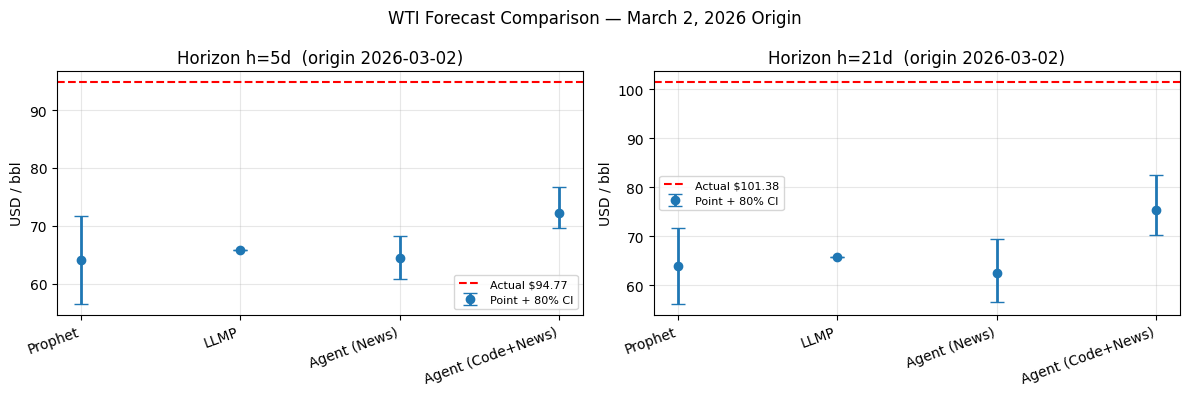

In [14]:
# Point forecast comparison chart (h=5 and h=21)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, h_idx, h in [(axes[0], 0, 5), (axes[1], 2, 21)]:
    names, points, lo, hi, actuals = [], [], [], [], []
    actual_val = get_actual(h)

    for name, preds in predictor_sets:
        if preds and h_idx < len(preds):
            fc = preds[h_idx].payload
            names.append(name)
            points.append(fc.point_forecast)
            lo.append(fc.quantiles[0.10])
            hi.append(fc.quantiles[0.90])

    x = range(len(names))
    ax.errorbar(
        x,
        points,
        yerr=[np.array(points) - np.array(lo), np.array(hi) - np.array(points)],
        fmt="o",
        capsize=5,
        linewidth=2,
        label="Point + 80% CI",
    )
    if actual_val:
        ax.axhline(actual_val, color="red", linestyle="--", label=f"Actual ${actual_val:.2f}")
    ax.set_xticks(list(x))
    ax.set_xticklabels(names, rotation=20, ha="right")
    ax.set_title(f"Horizon h={h}d  (origin {ORIGIN.date()})")
    ax.set_ylabel("USD / bbl")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("WTI Forecast Comparison — March 2, 2026 Origin", fontsize=12)
plt.tight_layout()
plt.show()

---
## Key Takeaways

1. **All four predictors share the same `Predictor` interface.** The same
   `predict(task, context)` call works whether the model is a statistical
   trend-fitter or a tool-using agent. This is what makes systematic
   backtesting in Notebook 4 possible.

2. **`AgentConfig` factories encapsulate capability.** By importing
   `build_wti_news_config()` and `build_wti_code_exec_config()` from
   `analyst_agent/`, the notebook stays clean — configs are reproducible and
   importable from any script or notebook.

3. **Skills guide code execution, not sklearn usage.** The two ADK skills
   (`statistical-analysis`, `trend-projection`) provide payload-aware code
   patterns and reference benchmarks the agent loads on demand. They teach
   effective use of code exec within the Gemini context-as-data-store
   constraints — not Python basics. Following the design rule in
   `docs/adk-skills-guide.md`, no scripts are present and the instruction
   explicitly forbids `run_skill_script`.

4. **Temporal cutoffs prevent data leakage.** The `ContextRetrievalConfig`
   sub-agent enforces a `cutoff_date` on every search call, allowing the same
   agent to be used safely in historical backtests.

→ **Notebooks 4–6** build on these four predictors: Notebook 4 runs a systematic
2025 backtest across all stateless methods; Notebooks 5–6 introduce the adaptive
agent and compare it against the stateless top-performers on held-out 2025+ data.